## Association Rules với FP-Growth Algorithm

Phân tích luật kết hợp để tìm các mẫu và mối quan hệ giữa các đặc trưng trong dữ liệu bệnh tim bằng thuật toán FP-Growth.

In [8]:
# Import thư viện cho Association Rules
from pathlib import Path
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Giả định DATA_PATH là file đã được tải lên
DATA_PATH = Path("heart.csv")
raw_df = pd.read_csv(DATA_PATH)
fpgrowth_df = raw_df.copy()

# 1. Tiền xử lý dữ liệu (Discretization & Mapping)
# Discretize các biến số liên tục thành categories
fpgrowth_df['age_group'] = pd.cut(fpgrowth_df['age'], 
                                  bins=[0, 45, 55, 65, 100], 
                                  labels=['Young', 'Middle', 'Senior', 'Elderly'])
fpgrowth_df['trestbps_group'] = pd.cut(fpgrowth_df['trestbps'],
                                       bins=[0, 120, 140, 200],
                                       labels=['Normal', 'Elevated', 'High'])
fpgrowth_df['chol_group'] = pd.cut(fpgrowth_df['chol'],
                                   bins=[0, 200, 240, 600],
                                   labels=['Normal', 'Borderline', 'High'])
fpgrowth_df['thalach_group'] = pd.cut(fpgrowth_df['thalach'],
                                      bins=[0, 120, 150, 250],
                                      labels=['Low', 'Normal', 'High'])
fpgrowth_df['oldpeak_group'] = pd.cut(fpgrowth_df['oldpeak'],
                                      bins=[-1, 0, 1, 2, 10],
                                      labels=['None', 'Mild', 'Moderate', 'Severe'])

# Chuyển đổi các biến categorical thành string format
fpgrowth_df['sex_str'] = fpgrowth_df['sex'].map({0: 'Female', 1: 'Male'})
fpgrowth_df['cp_str'] = fpgrowth_df['cp'].map({0: 'Typical', 1: 'Atypical', 2: 'Non-anginal', 3: 'Asymptomatic'})
fpgrowth_df['fbs_str'] = fpgrowth_df['fbs'].map({0: 'Normal_BS', 1: 'High_BS'})
fpgrowth_df['restecg_str'] = fpgrowth_df['restecg'].map({0: 'Normal_ECG', 1: 'ST-T_abnormal', 2: 'LVH'})
fpgrowth_df['exang_str'] = fpgrowth_df['exang'].map({0: 'No_ExAng', 1: 'ExAng'})
fpgrowth_df['slope_str'] = fpgrowth_df['slope'].map({0: 'Up', 1: 'Flat', 2: 'Down'})
fpgrowth_df['ca_str'] = fpgrowth_df['ca'].astype(str) + '_vessels'
fpgrowth_df['thal_str'] = fpgrowth_df['thal'].map({0: 'Normal', 1: 'Fixed', 2: 'Reversible', 3: 'Unknown'})
fpgrowth_df['target_str'] = fpgrowth_df['target'].map({0: 'No_Disease', 1: 'Heart_Disease'})

# Tạo transactions
transaction_data = []
columns_to_include = ['age_group', 'sex_str', 'cp_str', 'trestbps_group', 'chol_group', 'fbs_str', 'restecg_str', 'thalach_group', 'exang_str', 'oldpeak_group', 'slope_str', 'ca_str', 'thal_str', 'target_str']
for idx, row in fpgrowth_df.iterrows():
    transaction = [str(row[col]) for col in columns_to_include if pd.notna(row[col])]
    transaction_data.append(transaction)

# Encode transactions thành one-hot format
te = TransactionEncoder()
te_ary = te.fit(transaction_data).transform(transaction_data)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Số lượng transactions: {len(transaction_data)}")
print(f"Số lượng items: {len(te.columns_)}")
print(f"\nMột số items phổ biến:")
print(df_encoded.sum().sort_values(ascending=False).head(10))

Số lượng transactions: 1025
Số lượng items: 39

Một số items phổ biến:
Normal_BS        872
High             848
Male             713
No_ExAng         680
Normal           639
0_vessels        578
Reversible       544
Heart_Disease    526
ST-T_abnormal    513
No_Disease       499
dtype: int64



Số lượng frequent itemsets (max_len<=3): 1283

Top 10 frequent itemsets:


,support,itemsets
0,0.850732,(Normal_BS)
1,0.827317,(High)
2,0.695610,(Male)
33,0.690732,"(Normal_BS, High)"
3,0.663415,(No_ExAng)
19,0.623415,(Normal)
34,0.587317,"(Normal_BS, Male)"
37,0.575610,"(No_ExAng, High)"
38,0.572683,"(No_ExAng, Normal_BS)"
14,0.563902,(0_vessels)


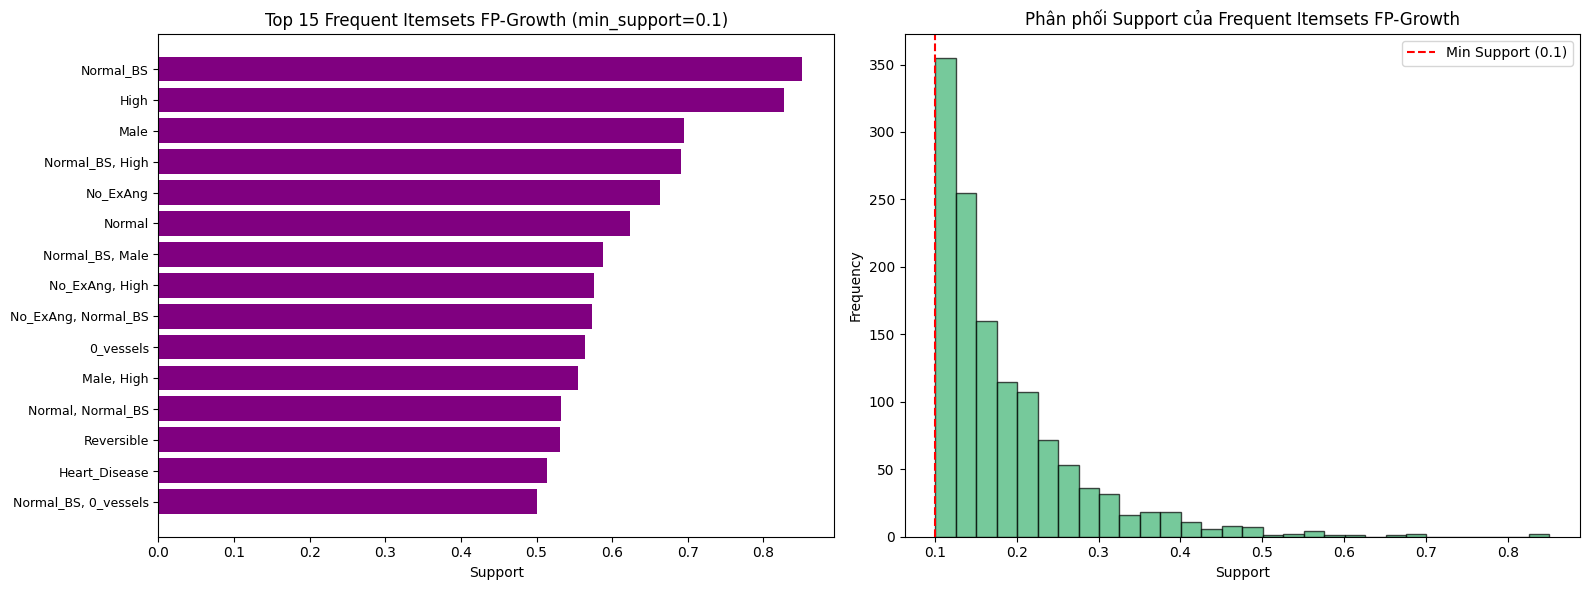

In [13]:
# 2. Tìm Frequent Itemsets với FP-Growth
min_support = 0.1
frequent_itemsets = fpgrowth(df_encoded, min_support=min_support, use_colnames=True) 

# Giới hạn max_len=3 (lọc sau)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets = frequent_itemsets[frequent_itemsets['length'] <= 3].drop(columns=['length'])

print(f"\nSố lượng frequent itemsets (max_len<=3): {len(frequent_itemsets)}")
print(f"\nTop 10 frequent itemsets:")
display(frequent_itemsets.sort_values('support', ascending=False).head(10))

# Visualize support của frequent itemsets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot cho top itemsets
top_itemsets = frequent_itemsets.sort_values('support', ascending=False).head(15)
top_itemsets['itemset_str'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
axes[0].barh(range(len(top_itemsets)), top_itemsets['support'], color='purple')
axes[0].set_yticks(range(len(top_itemsets)))
axes[0].set_yticklabels(top_itemsets['itemset_str'], fontsize=9)
axes[0].set_xlabel('Support')
axes[0].set_title(f'Top 15 Frequent Itemsets FP-Growth (min_support={min_support})')
axes[0].invert_yaxis()

# Distribution của support
axes[1].hist(frequent_itemsets['support'], bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Phân phối Support của Frequent Itemsets FP-Growth')
axes[1].axvline(min_support, color='red', linestyle='--', label=f'Min Support ({min_support})')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# Tạo Association Rules 
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Tính toán thêm các metrics
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
rules['rule'] = rules['antecedents_str'] + ' => ' + rules['consequents_str']

# CHỈ LẤY CÁC RULES CÓ TARGET (Heart_Disease hoặc No_Disease) LÀM CONSEQUENT 
# Điều này làm cho rules có ý nghĩa cho phân loại bệnh
rules['has_target'] = rules['consequents'].apply(
    lambda x: any('Heart_Disease' in str(item) or 'No_Disease' in str(item) for item in x)
)
rules_for_classification = rules[rules['has_target']].copy()

print(f"\nSố lượng association rules tổng cộng (FP-Growth): {len(rules)}")
print(f"Số lượng rules liên quan đến phân loại bệnh (có target trong consequent) (FP-Growth): {len(rules_for_classification)}")

print(f"\nTop 10 rules theo Support (giảm dần) - CHỈ RULES PHÂN LOẠI BỆNH (FP-Growth):")
display(rules_for_classification[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]
        .sort_values('support', ascending=False).head(10))

# CHỈ áp dụng cho rules phân loại bệnh
# Tăng ngưỡng để tìm rules mạnh hơn: support > 0.4 và confidence > 0.5 
strong_rules = rules_for_classification[
    (rules_for_classification['support'] > 0.4) & 
    (rules_for_classification['confidence'] > 0.5)
].copy()
print(f"\nSố lượng rules hợp lệ cho phân loại (support > 0.4 và confidence > 0.5) (FP-Growth): {len(strong_rules)}")

if len(strong_rules) > 0:
    # Tạo composite score kết hợp support và confidence
    # Score = support * confidence (cân bằng cả hai yếu tố)
    strong_rules['composite_score'] = strong_rules['support'] * strong_rules['confidence']
    
    print(f"\nTop 5 rules mạnh nhất cho phân loại bệnh (theo composite score = support × confidence) (FP-Growth):")
    top_rules = strong_rules.sort_values('composite_score', ascending=False).head(5)
    display(top_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift', 'composite_score']])


Số lượng association rules tổng cộng (FP-Growth): 2545
Số lượng rules liên quan đến phân loại bệnh (có target trong consequent) (FP-Growth): 314

Top 10 rules theo Support (giảm dần) - CHỈ RULES PHÂN LOẠI BỆNH (FP-Growth):


,antecedents_str,consequents_str,support,confidence,lift
2141,Normal_BS,Heart_Disease,0.443902,0.521789,1.016794
2138,No_ExAng,Heart_Disease,0.443902,0.669118,1.303889
2143,High,Heart_Disease,0.440000,0.531840,1.036379
2145,0_vessels,Heart_Disease,0.404878,0.717993,1.399131
144,Male,No_Disease,0.402927,0.579243,1.189827
2146,Reversible,Heart_Disease,0.401951,0.757353,1.475830
2156,"No_ExAng, High",Heart_Disease,0.386341,0.671186,1.307920
2158,No_ExAng,"Heart_Disease, High",0.386341,0.582353,1.323529
2151,"No_ExAng, Normal_BS",Heart_Disease,0.380488,0.664395,1.294687
2153,No_ExAng,"Heart_Disease, Normal_BS",0.380488,0.573529,1.292017



Số lượng rules hợp lệ cho phân loại (support > 0.4 và confidence > 0.5) (FP-Growth): 6

Top 5 rules mạnh nhất cho phân loại bệnh (theo composite score = support × confidence) (FP-Growth):


,antecedents_str,consequents_str,support,confidence,lift,composite_score
2146,Reversible,Heart_Disease,0.401951,0.757353,1.475830,0.304419
2138,No_ExAng,Heart_Disease,0.443902,0.669118,1.303889,0.297023
2145,0_vessels,Heart_Disease,0.404878,0.717993,1.399131,0.290700
2143,High,Heart_Disease,0.440000,0.531840,1.036379,0.234009
144,Male,No_Disease,0.402927,0.579243,1.189827,0.233392


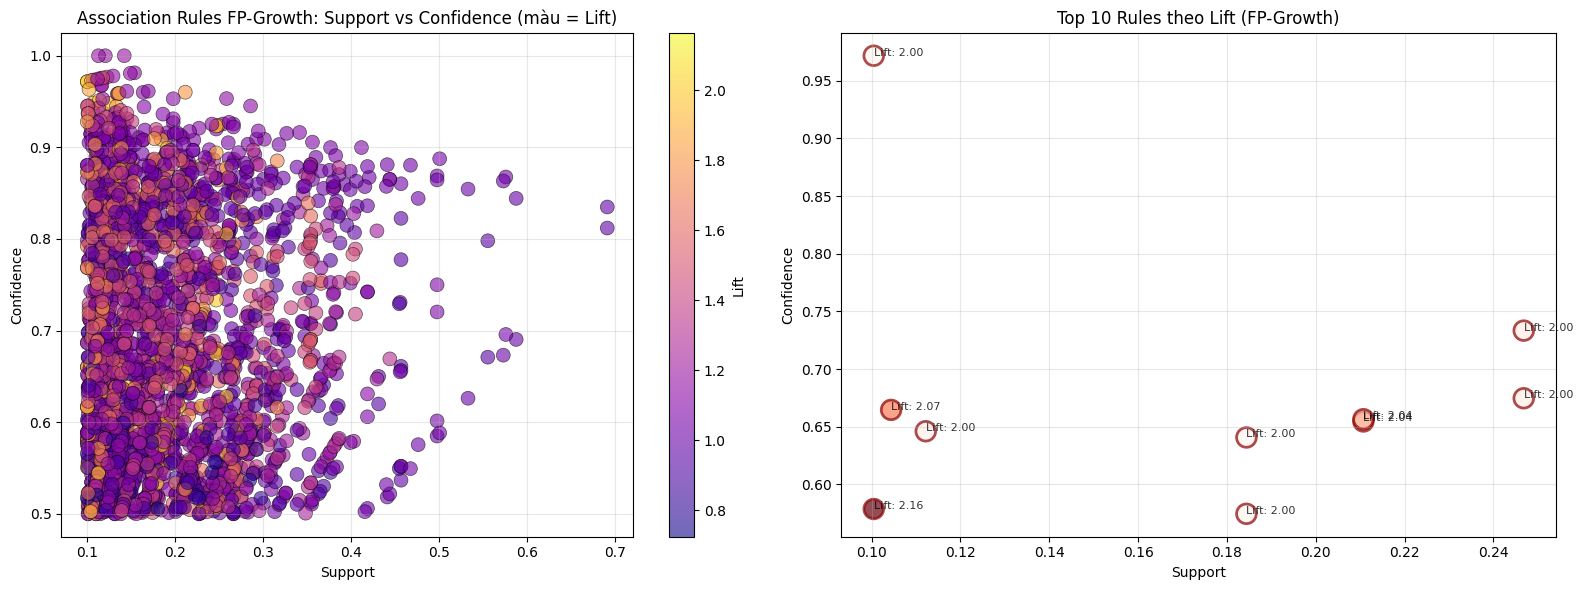

In [17]:
# 4. Visualization 1: Scatter plot Confidence vs Support (màu theo Lift)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(rules['support'], rules['confidence'], 
                           c=rules['lift'], cmap='plasma', 
                           s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Association Rules FP-Growth: Support vs Confidence (màu = Lift)')
# Điều chỉnh: Sử dụng plt.colorbar với ax=axes[0] để tránh warning
fig.colorbar(scatter1, ax=axes[0], label='Lift') 
axes[0].grid(True, alpha=0.3)

# Top rules theo lift
top_rules = rules.nlargest(10, 'lift')
axes[1].scatter(top_rules['support'], top_rules['confidence'], 
               s=200, alpha=0.7, c=top_rules['lift'], cmap='Reds', 
               edgecolors='darkred', linewidth=2)
for idx, row in top_rules.iterrows():
    axes[1].annotate(f"Lift: {row['lift']:.2f}", 
                     (row['support'], row['confidence']),
                     fontsize=8, alpha=0.8)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Top 10 Rules theo Lift (FP-Growth)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

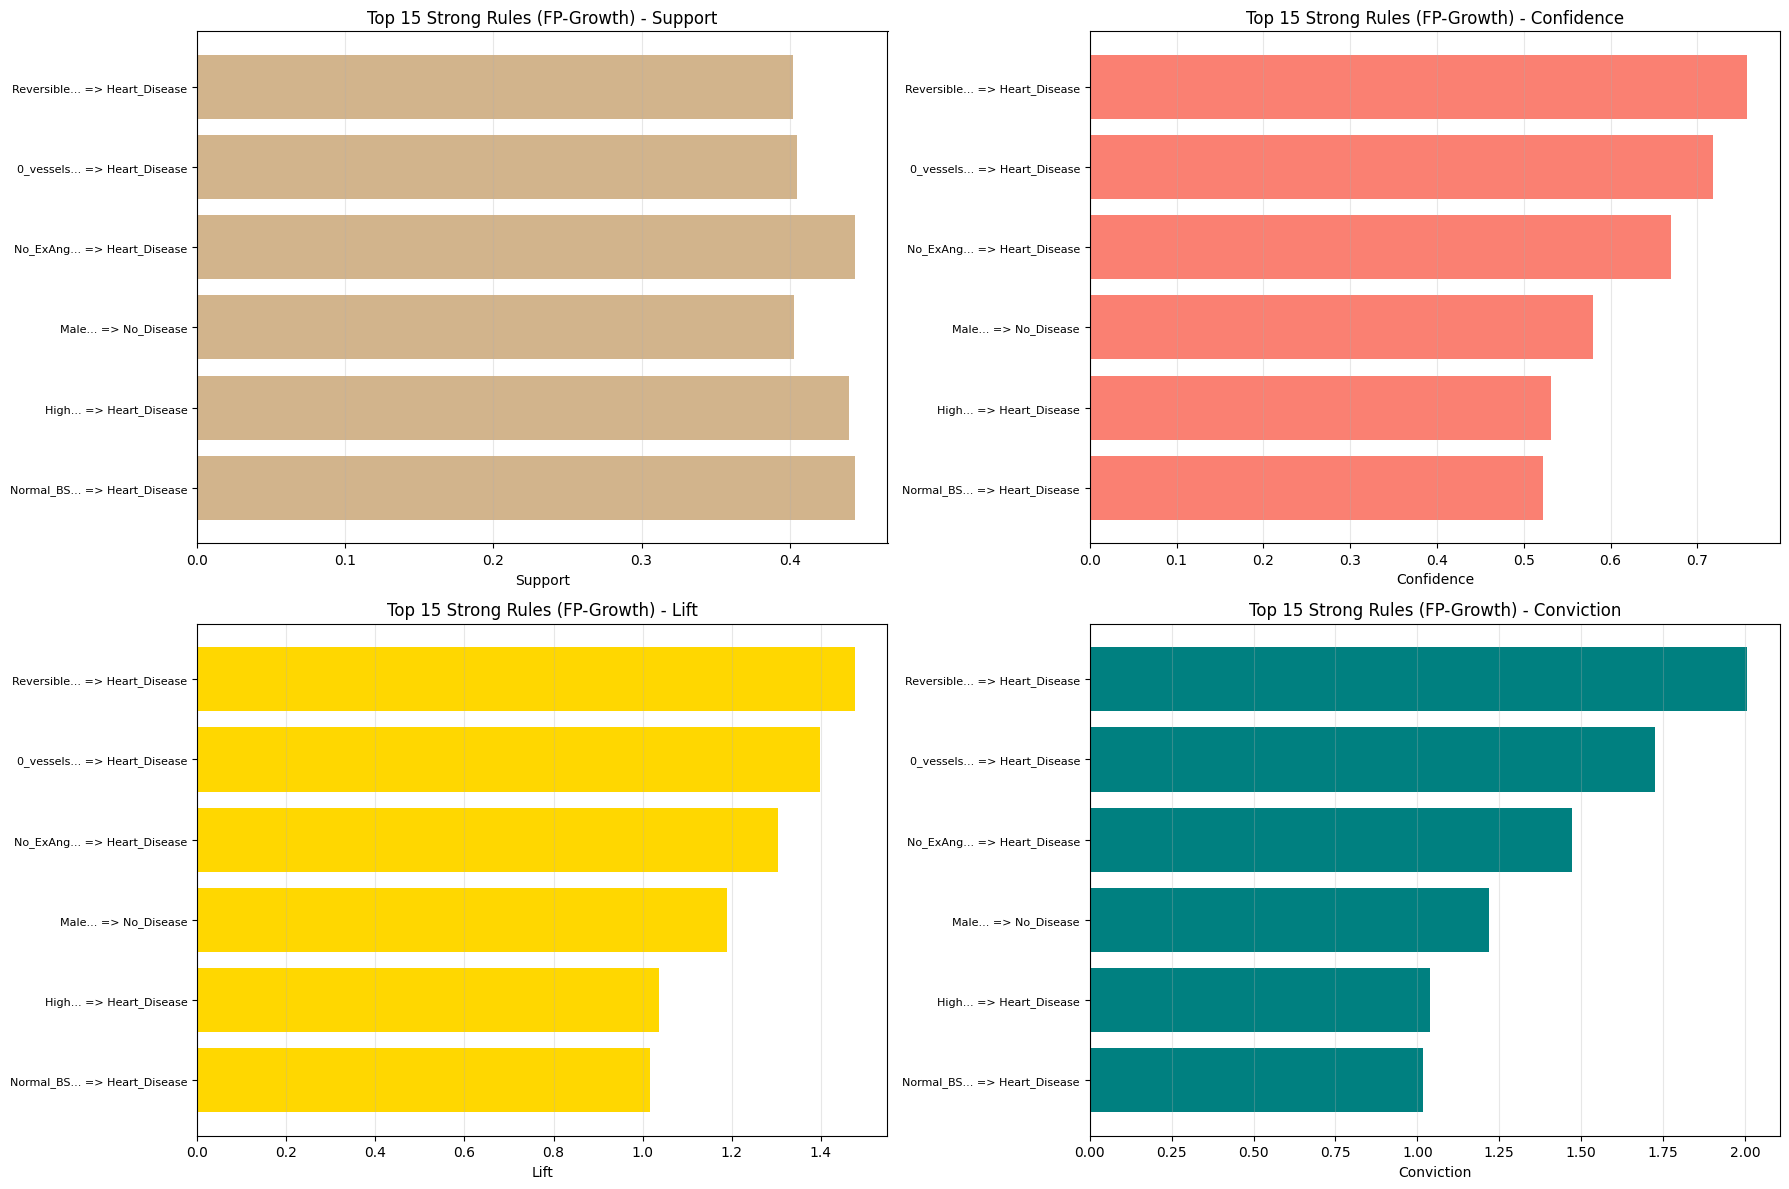

In [18]:
if len(strong_rules) > 0:
    top_strong = strong_rules.nlargest(15, 'lift')
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Support
    axes[0, 0].barh(range(len(top_strong)), top_strong['support'], color='tan')
    axes[0, 0].set_yticks(range(len(top_strong)))
    axes[0, 0].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                 for _, row in top_strong.iterrows()], fontsize=8)
    axes[0, 0].set_xlabel('Support')
    axes[0, 0].set_title('Top 15 Strong Rules (FP-Growth) - Support')
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # Confidence
    axes[0, 1].barh(range(len(top_strong)), top_strong['confidence'], color='salmon')
    axes[0, 1].set_yticks(range(len(top_strong)))
    axes[0, 1].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                 for _, row in top_strong.iterrows()], fontsize=8)
    axes[0, 1].set_xlabel('Confidence')
    axes[0, 1].set_title('Top 15 Strong Rules (FP-Growth) - Confidence')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    # Lift
    axes[1, 0].barh(range(len(top_strong)), top_strong['lift'], color='gold')
    axes[1, 0].set_yticks(range(len(top_strong)))
    axes[1, 0].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                 for _, row in top_strong.iterrows()], fontsize=8)
    axes[1, 0].set_xlabel('Lift')
    axes[1, 0].set_title('Top 15 Strong Rules (FP-Growth) - Lift')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # Conviction
    if 'conviction' in top_strong.columns:
        axes[1, 1].barh(range(len(top_strong)), top_strong['conviction'], color='teal')
        axes[1, 1].set_yticks(range(len(top_strong)))
        axes[1, 1].set_yticklabels([f"{row['antecedents_str'][:30]}... => {row['consequents_str']}" 
                                     for _, row in top_strong.iterrows()], fontsize=8)
        axes[1, 1].set_xlabel('Conviction')
        axes[1, 1].set_title('Top 15 Strong Rules (FP-Growth) - Conviction')
        axes[1, 1].invert_yaxis()
        axes[1, 1].grid(axis='x', alpha=0.3)
    else:
        axes[1, 1].axis('off')
        axes[1, 1].text(0.5, 0.5, 'Conviction metric not available', 
                        ha='center', va='center', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('Top_Strong_Rules_Metrics_FPgrowth.png')
else:
    print("Không có rules nào thỏa mãn điều kiện (support > 0.4 và confidence > 0.5)")